In [44]:
import os
import pandas as pd
from openai import OpenAI

import numpy as np
import json
from dotenv import load_dotenv
import pickle

import tiktoken
from copy import deepcopy
import re
from tqdm import tqdm 

In [45]:
repo_dir = "/Users/haya1/Documents/LanguageModel_Labels/congressional_bills"
os.chdir(repo_dir)

# Place API_KEY in the .env file
load_dotenv()
client = OpenAI(api_key=os.environ.get('OPENAI_API_KEY_ASHESH'))
# client = OpenAI(api_key=os.environ.get('OPENAI_API_KEY'))

data_dir = os.path.join(repo_dir, "01_bills")
llm_dir = os.path.join(repo_dir, "02_llm")

## Generate prompts

### Create `prompting_strategies.csv`

In [46]:
# Create the MAJOR_TEXT dictionary
MAJOR_TEXT = pd.read_csv(os.path.join(data_dir, "majors.csv")).set_index('Major')['MajorText'].to_dict()

# Create the CATEGORIES string
CATEGORIES = "\n".join([f"{int(major)}. {text}" for major, text in MAJOR_TEXT.items()])

QUESTION =f"""Here is a description of a bill introduced in the U.S. Congress:
"{{0}}"

Please classify this description into one of the following categories:
{CATEGORIES}
"""

ANSWER_JSON = f"""Output a JSON object structured like: {{{{
    "Category": an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} that best represents the bill category,
    "Confidence": confidence level in the bill classification as a number between 0 to 1 with 2 decimal places
}}}}
"""

ANSWER_JSON_EXPLANATION = f"""Output a JSON object structured like: {{{{
    "Category": an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} that best represents the bill category,
    "Confidence": confidence level in the bill classification as a number between 0 to 1 with 2 decimal places,
    "Explanation": a one-sentence explanation for your chosen bill category
}}}}
"""

ANSWER_BLANKS = f"""Write your answer as:
____ (fill in with an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} that best represents the bill category),
____ (fill in with confidence level in the bill classification as a number between 0 to 1 with 2 decimal places)
"""

ANSWER_BLANKS_EXPLANATION = f"""Write your answer as:
____ (fill in with an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} that best represents the bill category),
____ (fill in with confidence level in the bill classification as a number between 0 to 1 with 2 decimal places),
____ (fill in with a one-sentence explanation for your chosen bill category)
"""

In [47]:
# prompting_strategies_csv_path = os.path.join(llm_dir, "prompting_strategies.csv")
# if os.path.exists(prompting_strategies_csv_path):
#     prompting_strategies = pd.read_csv(prompting_strategies_csv_path)
# else:
prompting_strategies = pd.DataFrame(data = {
    "PromptingStrategyName": [
        "Base Prompt", "Base Prompt", 
        "Persona", "Persona", "Persona", "Persona", 
        "Chain-of-Thoughts", "Chain-of-Thoughts", "Chain-of-Thoughts", 
        "Few-Shot", "Few-Shot", "Few-Shot"
        ],

    "Text": [
        None, None, 
        "You are a knowledgeable political analyst. ",
        "Answer this question as if you are a political scientist that studies legislation in the United States Congress. ",
        "Answer this question as if you are an expert in United States politics. ",
        "Answer this question as if you were a helpful research assistant for a political scientist. ",
        "Think carefully. ", 
        "Let's think step by step. Lay out each step. ", 
        "Please provide an explanation for your answer. ",
        None, None, None,
        ],

    "TextLocation": [
        None, None, 
        "before", "before", "before", "before", 
        "after", "after", "after", 
        None, None, None],

    "ExamplesPath": [
        None, None, 
        None, None, None, None, 
        None, None, None, 
        os.path.join(data_dir, "examples01.csv"),
        os.path.join(data_dir, "examples02.csv"),
        os.path.join(data_dir, "examples03.csv")
    ],

    "ResponseFormat": [
        "Fill-in-the-Blanks", "JSON", 
        "JSON", "JSON", "JSON", "JSON", 
        "JSON", "JSON", "JSON", 
        "JSON", "JSON", "JSON"
    ],

    # InputTokens and OuputTokens estimations are based on average run of 100 bills
    "InputTokensAverage": [
        239.96, 242.96, 
        249.96, 261.96, 256.96, 258.96, 
        260.96, 269.96, 265.96, 
        1599.96, 1562.96, 1547.96
    ], 
    "InputTokensSD": [12.53]*12, 
    "OutputTokensAverage": [
        5.96, 19, 
        19, 19, 19, 19, 
        47.56, 47.47, 48.36, 
        15, 15, 15
    ], 
    "OutputTokensSD": [
        0.2, 0.00, 
        0.00, 0.00, 0.00, 0.00, 
        4.41, 4.72, 5.29, 
        0.00, 0.00, 0.00]
})
prompting_strategies.insert(loc=4, column="AddExamples", value=prompting_strategies["PromptingStrategyName"] == "Few-Shot")
prompting_strategies["AddExplanation"] = prompting_strategies["PromptingStrategyName"] == "Chain-of-Thoughts"

n = len(prompting_strategies)
prompting_strategies = pd.concat([prompting_strategies, prompting_strategies], ignore_index=True)
prompting_strategies["Model"] = ["gpt-3.5-turbo-0125"]*n + ["gpt-4o"]*n
ModelInputCost_perToken = [0.50/1e6]*n + [5.00/1e6]*n # + [0.150/1e6]*n
ModelOutputCost_perToken = [1.50/1e6]*n + [15.0/1e6]*n # + [0.60/1e6]*n

prompting_strategies["TotalCostAverage_per10KBills"] = (
    (prompting_strategies["InputTokensAverage"] * ModelInputCost_perToken) + 
    (prompting_strategies["OutputTokensAverage"] * ModelOutputCost_perToken)) * 10e3

prompting_strategies.insert(loc=0, column="PromptingStrategyID", value = list(range(1, len(prompting_strategies)+1)))

prompting_strategies["Temperature"] = 0 
prompting_strategies.to_csv(os.path.join(llm_dir, "prompting_strategies.csv"), index=False, float_format='%.2f')

## Create `prompts.jsonl`

In [48]:
def create_content_user(strategy):
    question = QUESTION + "\n"
    if strategy["TextLocation"] == "before":
        question = strategy["Text"] + question
    elif strategy["TextLocation"] == "after":
        question = question + strategy["Text"]

    if strategy["ResponseFormat"]=="JSON":
        if strategy["AddExplanation"]:
            answer = ANSWER_JSON_EXPLANATION
        else:
            answer = ANSWER_JSON
    else:
        if strategy["AddExplanation"]:
            answer = ANSWER_BLANKS_EXPLANATION
        else:
            answer = ANSWER_BLANKS

    content = question + answer
    return content

def create_content_assistant(strategy, category, confidence, explanation=None):
    if strategy["ResponseFormat"]=="JSON":
        if strategy["AddExplanation"]:

            if explanation is None:
                raise Exception("AddExplanation=True but explanation=None. You need to pass a string to explanation variable")
            
            correct_answer = {
                "Category": category,
                "Confidence": np.round(confidence, decimals=2),
                "Explanation": explanation
            }
        else:
            correct_answer = {
                "Category": category,
                "Confidence": np.round(confidence, decimals=2)
            }
        content = json.dumps(correct_answer)

    else:
        if strategy["AddExplanation"]:

            if explanation is None:
                raise Exception("AddExplanation=True but explanation=None. You need to pass a string to explanation variable")
            
            correct_answer = "%d, %.2f, %s\n" % (category, confidence, explanation)
        else:
            correct_answer = "%d, %.2f\n" % (category, confidence)
        content = correct_answer

    return content

def create_messages(strategy, min_confidence, max_confidence=1, examples_via_system=True):
    messages = []

    if strategy["AddExamples"]:
        bills_examples = pd.read_csv(strategy["ExamplesPath"])
        
        for _, bill in bills_examples.iterrows():
            message_user_content = create_content_user(strategy).format(bill["Description"])

            if examples_via_system:
                message_user = {"role": "system", "name": "example_user", "content": message_user_content}
            else:
                message_user = {"role": "user", "content": message_user_content}
            messages.append(message_user)

            message_assistant_content = create_content_assistant(strategy, category=bill["Major"], confidence=np.random.uniform(min_confidence, max_confidence))
            if examples_via_system:
                message_assistant = {"role": "system", "name": "example_assistant", "content": message_assistant_content}
            else:
                message_assistant = {"role": "assistant", "content": message_assistant_content}
            messages.append(message_assistant)
    
    message_user_content = create_content_user(strategy)
    message_user = {"role": "user", "content": message_user_content}
    messages.append(message_user)
    return messages

def count_tokens(messages, model="gpt-3.5-turbo"):
    encoding = tiktoken.encoding_for_model(model)
    
    if model in {"gpt-3.5-turbo-0125", "gpt-3.5-turbo", "gpt-4o"}:
        tokens_per_message = 3
        tokens_per_name = 1
    else:
        raise NotImplementedError(f"No implementation for model {model}.")
    num_tokens = 0
    for message in messages:
        num_tokens += tokens_per_message
        for key, value in message.items():
            num_tokens += len(encoding.encode(value))
            if key == "name":
                num_tokens += tokens_per_name
    num_tokens += 3  # every reply is primed with <|start|>assistant<|message|>
    return num_tokens

In [53]:
n = 10000
prompting_strategies = pd.read_csv(os.path.join(llm_dir, "prompting_strategies.csv"))
bills = pd.read_csv(os.path.join(data_dir, f"bills_without_examples_{n}.csv"))
prompts_path = os.path.join(llm_dir, f"prompts_{n}.jsonl")

prompting_strategies_json = []
for _, strategy in prompting_strategies.iterrows():
    strategy_json = {
        "PromptingStrategyID": strategy["PromptingStrategyID"],
        "PromptingStrategyName": strategy["PromptingStrategyName"],
        "ResponseFormat": strategy["ResponseFormat"],
        "AddExplanation": strategy["AddExplanation"],
        "AddExamples": strategy["AddExamples"],
        "Model": strategy["Model"],
        "Temperature": strategy["Temperature"],
        "Messages": create_messages(strategy, min_confidence=0.9, max_confidence=1, examples_via_system=True)
    }
    prompting_strategies_json.append(strategy_json)
    
prompting_strategies_json = pd.json_normalize(prompting_strategies_json)

id = 0
prompts = []
for _, bill in bills.iterrows():
    for _, strategy in prompting_strategies_json.iterrows():
        
        # add bill to last used message
        bill_messages = deepcopy(strategy["Messages"])
        bill_messages[-1]["content"] = bill_messages[-1]["content"].format(bill["Description"])
        
        input_tokens = count_tokens(bill_messages, strategy['Model'])
        output_tokens = 0

        id = id + 1
        prompt = {
            "ID": id,
            "BillID": bill["BillID"],
            "PromptingStrategyID": strategy["PromptingStrategyID"],
            "Description": bill["Description"],
            "PromptingStrategyName": strategy["PromptingStrategyName"],
            "ResponseFormat": strategy["ResponseFormat"],
            "AddExplanation": strategy["AddExplanation"],
            "AddExamples": strategy["AddExamples"],
            "Model": strategy["Model"],
            "Temperature": strategy["Temperature"],
            "Major": bill["Major"],
            "MajorText": bill["MajorText"],
            "InputTokens": input_tokens,
            "Messages": bill_messages
        }
        prompts.append(prompt)


with open(prompts_path, "w") as f:
    for prompt in prompts:
        f.write(json.dumps(prompt) + "\n")
print(f"Saved {prompts_path}")

Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/prompts_10000.jsonl


### Create `prompts_batched.jsonl`

In [54]:
prompts = pd.read_json(prompts_path, lines=True)

# separate models as batching allow one model at a time
for model in prompts["Model"].unique():
    prompts_batch_path = os.path.join(llm_dir, f"prompts_batched_{n}_{model}.jsonl")
    
    prompts_batched = []
    
    for _, prompt in prompts.iterrows():
        if (prompt["Model"] == model):
            prompt_batched = {
                "custom_id": "ID_" + str(prompt["ID"]),
                "method": "POST",
                "url": "/v1/chat/completions",
                "body": {
                    "model": prompt["Model"],
                    "temperature": prompt["Temperature"],
                    "response_format": {"type": "json_object"} if (prompt["ResponseFormat"]=="JSON") else None,
                    "messages": prompt["Messages"],
                }
            }
            prompts_batched.append(prompt_batched)
        
    
    with open(prompts_batch_path, "w") as f:
        for prompt_batched in prompts_batched:
            f.write(json.dumps(prompt_batched) + "\n")
        print(f"Saved {prompts_batch_path}")

Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/prompts_batched_10000_gpt-3.5-turbo-0125.jsonl
Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/prompts_batched_10000_gpt-4o.jsonl


## Predict cost

In [55]:
prompts = pd.read_json(prompts_path, lines=True)
prompting_strategies.set_index("PromptingStrategyID", inplace=True, drop=False) 
prompts["OutputTokensAverage"] = prompts["PromptingStrategyID"].apply(lambda x: prompting_strategies.loc[x, "OutputTokensAverage"])

ModelInputCost_perToken = [0.50/1e6]*int(len(prompts)/2) + [5.00/1e6]*int(len(prompts)/2) # + [0.150/1e6]*n
ModelOutputCost_perToken = [1.50/1e6]*int(len(prompts)/2) + [15.0/1e6]*int(len(prompts)/2) # + [0.60/1e6]*n
cost = (prompts["InputTokens"] * ModelInputCost_perToken).sum() + (prompts["OutputTokensAverage"] * ModelOutputCost_perToken).sum()
print(f"Expected cost of this run: ${cost:.2f}")

Expected cost of this run: $441.35


## Generate responses

In [52]:
batches = {}

for model in prompts["Model"].unique(): # ["gpt-3.5-turbo-0125", "gpt-4o"]

    prompts_batched_path = os.path.join(llm_dir, f"prompts_batched_{n}_{model}.jsonl")

    batch_input_file = client.files.create(
        file = open(prompts_batched_path, "rb"),
        purpose = "batch"
    )
    batch_input_file_id = batch_input_file.id
    batch = client.batches.create(
            input_file_id = batch_input_file_id,
            endpoint = "/v1/chat/completions",
            completion_window = "24h",
            metadata = {"description": "1K bills test"}
        )
    
    batches[model] = batch.id

batches

{'gpt-3.5-turbo-0125': 'batch_tSVIpwOEqYLYIxrzneZ38Cf8',
 'gpt-4o': 'batch_Qi4lin1f66j96pho3ofhRxyl'}

In [192]:
# batches = {
#     'gpt-3.5-turbo-0125': 'batch_tSVIpwOEqYLYIxrzneZ38Cf8',
#     'gpt-4o': 'batch_Qi4lin1f66j96pho3ofhRxyl'
#     }

In [195]:
for model in batches:
    id = batches[model]
    batch_status = client.batches.retrieve(id)
    if batch_status.status != "completed":
        raise AssertionError(f"{model} run is not completed, Batch ID = {id}")

In [196]:
for model in batches:
    responses_batched_path = os.path.join(llm_dir, f"responses_batched_{n}_{model}.jsonl")
    id = batches[model]
    batch_status = client.batches.retrieve(id)

    output_file_id = batch_status.output_file_id
    responses_batched = client.files.content(output_file_id)
    responses_batched.write_to_file(responses_batched_path)
    
    print(f"Saved raw responses at {responses_batched_path}")


Saved raw responses at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_48_gpt-3.5.jsonl
Saved raw responses at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_48_gpt-4o.jsonl


## Decode Responses

In [197]:
prompts = pd.read_json(prompts_path, lines=True)
prompts.set_index("ID", inplace=True, drop=False)

In [205]:
responses_batched = []
for model in batches:
    responses_batched_model = pd.read_json(os.path.join(llm_dir, f"responses_batched_{n}_{model}.jsonl"), lines=True)
    responses_batched.append(responses_batched_model)

responses_batched = pd.concat(responses_batched)
responses_batched["ID"] = responses_batched["custom_id"].apply(lambda x: int(x[3:]))
responses_batched.set_index("ID", inplace=True, drop=False)

In [209]:
responses_path = os.path.join(llm_dir, f"responses_{n}.csv")

responses = []
for i in range(len(responses_batched)):
    response_batched = responses_batched.iloc[i]
    prompt = prompts.iloc[i] # [prompts["ID"]==response_batched["ID"]]
    
    response_text = response_batched.response["body"]["choices"][0]["message"]["content"]

    if prompt["ResponseFormat"]=="JSON":
        temp = json.loads(response_text)
        major = int(temp["Category"])
        response = {
            "ID": prompt["ID"],
            "MajorLLM": major,
            "MajorTextLLM": MAJOR_TEXT[major],
            "ConfidenceLLM": float(temp["Confidence"]),
            "ExplanationLLM": temp["Explanation"] if prompt["AddExplanation"] else None
        }

    else:
        single_entry_pattern = r'^(\d+)\s*[,]{0,1}\s*[\r\n]{0,1}\s*([0-9]\.[0-9]{2})\s*[,]{0,1}[\r\n]{0,1}?\s*(.*)?$'
        multiple_entries_pattern = r'((\d+)\s*\.\s*([\d\.]+)\s*\n)' 

        if re.match(single_entry_pattern, response_text):
            match = re.match(single_entry_pattern, response_text)
            major = int(match.group(1))
            response = {
                "ID": prompt["ID"],
                "MajorLLM": major,
                "MajorTextLLM": MAJOR_TEXT[major],
                "ConfidenceLLM": float(match.group(2)),
                "ExplanationLLM": match.group(3) if prompt["AddExplanation"] else None
            }
        elif re.findall(multiple_entries_pattern, response_text):
            matches = re.findall(multiple_entries_pattern, response_text)
            match = max(matches, key=lambda x: float(x[2]))
            major = int(match[1])
            explanation = re.split('\n', response_text)[-1]
            response = {
                "ID": prompt["ID"],
                "MajorLLM": major,
                "MajorTextLLM": MAJOR_TEXT[major],
                "ConfidenceLLM": float(match[2]),
                "ExplanationLLM": explanation if prompt["AddExplanation"] else None
            }

    response["InputTokens"] = int(response_batched.response["body"]["usage"]["prompt_tokens"])
    response["OutputTokens"] = int(response_batched.response["body"]["usage"]["completion_tokens"])
    responses.append(response)

pd.json_normalize(responses).to_csv(responses_path, index=False, float_format='%.2f')    
print(f"Saved decoded responses at {responses_path}")

Saved decoded responses at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses.csv


In [210]:
# Merge prompts and responses datasets
prompts_path = os.path.join(llm_dir, f"prompts_{n}.jsonl")
responses_path = os.path.join(llm_dir, f"responses_{n}.csv")

prompts = pd.read_json(prompts_path, lines=True)
prompts.drop(columns=["Messages", "InputTokens"], inplace=True)
responses = pd.read_csv(responses_path)

prompts_and_responses = prompts.merge(responses, on="ID")
prompts_and_responses.to_csv(os.path.join(llm_dir, "prompts_and_responses.csv"), index=False, float_format='%.2f')
print(f"Merged prompts and responses data, n = {len(prompts_and_responses)}. Saved at {llm_dir}")
prompts_and_responses.head()

Merged prompts and responses data, n = 48. Saved at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm


,ID,BillID,PromptingStrategyID,Description,PromptingStrategyName,ResponseFormat,AddExplanation,AddExamples,Model,Temperature,Major,MajorText,MajorLLM,MajorTextLLM,ConfidenceLLM,ExplanationLLM,InputTokens,OutputTokens
0,1,88-S-1173,1,A bill to change the name of Short Mountain lo...,Base Prompt,Fill-in-the-Blanks,False,False,gpt-3.5-turbo-0125,0,20,Public Lands and Water Management,20,Public Lands and Water Management,0.95,NaN,240,6
1,2,88-S-1173,2,A bill to change the name of Short Mountain lo...,Base Prompt,JSON,False,False,gpt-3.5-turbo-0125,0,20,Public Lands and Water Management,20,Public Lands and Water Management,0.95,NaN,243,19
2,3,88-S-1173,3,A bill to change the name of Short Mountain lo...,Persona,JSON,False,False,gpt-3.5-turbo-0125,0,20,Public Lands and Water Management,20,Public Lands and Water Management,0.85,NaN,250,19
3,4,88-S-1173,4,A bill to change the name of Short Mountain lo...,Persona,JSON,False,False,gpt-3.5-turbo-0125,0,20,Public Lands and Water Management,20,Public Lands and Water Management,0.95,NaN,262,19
4,5,88-S-1173,5,A bill to change the name of Short Mountain lo...,Persona,JSON,False,False,gpt-3.5-turbo-0125,0,20,Public Lands and Water Management,20,Public Lands and Water Management,0.95,NaN,257,19


## Unique MajorLLM

In [41]:
import os
import pandas as pd
import matplotlib.pyplot as plt

repo_dir = "/Users/haya1/Documents/LanguageModel_Labels/congressional_bills"
prompts_and_responses = pd.read_csv(os.path.join(repo_dir, "02_llm/prompts_and_responses.csv"))
n_bills = len(prompts_and_responses['BillID'].unique())
n_strategies = len(prompts_and_responses["PromptingStrategyID"].unique())
n_major = len(prompts_and_responses['Major'].unique())
print(f"Loaded responses.csv data, n = {len(prompts_and_responses)}")
print(f"Number of bills = {n_bills}")
print(f"Number of prompting strategies per bill = {n_strategies}")
print(f"Number of Major topic IDs = {n_major}")


Loaded responses.csv data, n = 1200
Number of bills = 100
Number of prompting strategies per bill = 12
Number of Major topic IDs = 19


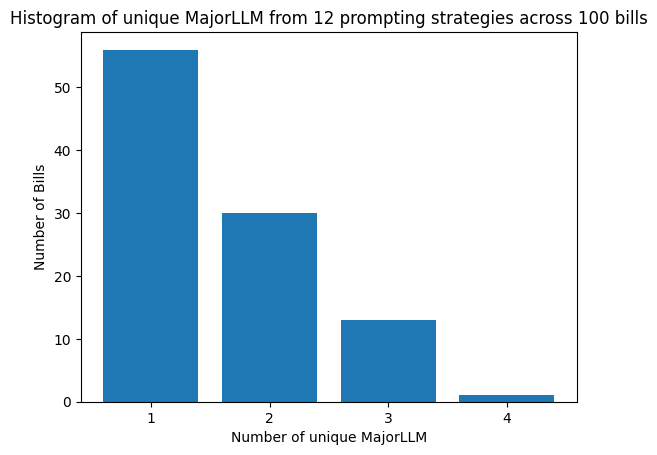

In [42]:
stat = prompts_and_responses.groupby(["BillID"]).agg(
    UniqueMajorLLM = ("MajorLLM", "nunique")
    ).reset_index()

labels, counts = np.unique(stat["UniqueMajorLLM"], return_counts=True)
plt.bar(labels, counts, align='center')
plt.gca().set_xticks(labels)
plt.title(f'Histogram of unique MajorLLM from {n_strategies} prompting strategies across {n_bills} bills')
plt.xlabel('Number of unique MajorLLM')
plt.ylabel('Number of Bills')
plt.show()

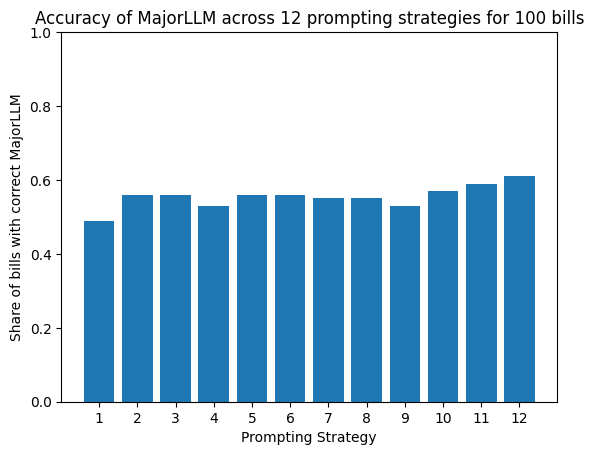

In [43]:
prompts_and_responses["CorrectMajorLLM"] = prompts_and_responses["Major"] == prompts_and_responses["MajorLLM"]
stat = prompts_and_responses.groupby(["PromptingStrategyID"]).agg(
    MeanCorrectMajorLLM = ("CorrectMajorLLM","mean")
).reset_index()
# labels, counts = np.unique(unique_MajorLLM["unique_count"], return_counts=True)
plt.bar(stat["PromptingStrategyID"], stat["MeanCorrectMajorLLM"], align='center')
plt.gca().set_xticks(stat["PromptingStrategyID"])
plt.title(f'Accuracy of MajorLLM across {n_strategies} prompting strategies for {n_bills} bills')
plt.xlabel('Prompting Strategy')
plt.ylabel('Share of bills with correct MajorLLM')
plt.ylim((0,1))
plt.show()


In [44]:
prompts_and_responses["PromptingStrategyName"].unique()

array(['Base Prompt', 'Persona', 'Chain-of-Thoughts', 'Few-Shot'],
      dtype=object)

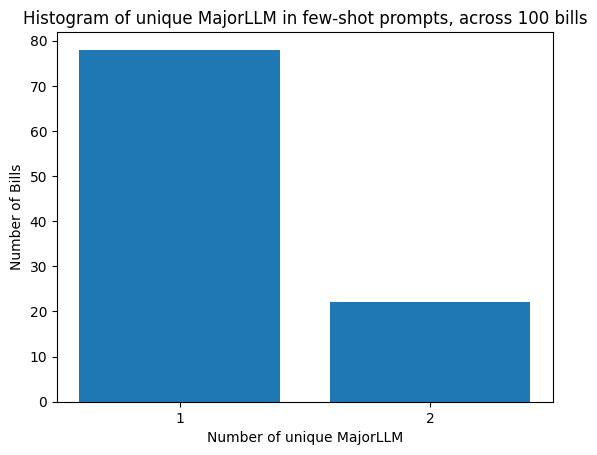

In [45]:
prompts_and_responses = prompts_and_responses[prompts_and_responses["PromptingStrategyName"]=="Few-Shot"]
stat = prompts_and_responses.groupby(["BillID"]).agg(
    UniqueMajorLLM = ("MajorLLM", "nunique")
    ).reset_index()

labels, counts = np.unique(stat["UniqueMajorLLM"], return_counts=True)
plt.bar(labels, counts, align='center')
plt.gca().set_xticks(labels)
plt.title(f'Histogram of unique MajorLLM in few-shot prompts, across {n_bills} bills')
plt.xlabel('Number of unique MajorLLM')
plt.ylabel('Number of Bills')
plt.show()